# Booking Demand Analysis: *OLS Regression*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import json
import warnings
warnings.filterwarnings('ignore')

# Global plot styling
plt.rcParams.update({
    'figure.facecolor':  '#FAFAF8',
    'axes.facecolor':    '#F5F5F3',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11
})

### 1. Loading data & inspecting missing values

In [ ]:
df = pd.read_csv("../data/listings.csv")

# Keeping only the columns relevant to the analysis
cols = [
    'reviews_per_month',          # target variable (demand proxy)
    'instant_bookable',           # key predictor 
    'host_response_time',         # host engagement signal
    'host_acceptance_rate',       # host flexibility signal
    'amenities',                  # product depth (needs parsing)
    'price',                      # pricing signal (needs cleaning)
    'room_type',                  # product category (control)
    'neighbourhood_group_cleansed'# location (control)
]

df = df[cols].copy()

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
display(df.head())

Shape: (14274, 8)

Missing values:
reviews_per_month               3314
instant_bookable                   0
host_response_time              5018
host_acceptance_rate            4478
amenities                          0
price                           5010
room_type                          0
neighbourhood_group_cleansed       0
dtype: int64


,reviews_per_month,instant_bookable,host_response_time,host_acceptance_rate,amenities,price,room_type,neighbourhood_group_cleansed
0,0.76,f,within a day,83%,"[""Cooking basics"", ""Wine glasses"", ""Crib"", ""Ho...",$105.00,Entire home/apt,Pankow
1,0.06,f,a few days or more,0%,"[""Cooking basics"", ""Crib"", ""Stove"", ""Elevator""...",$135.00,Entire home/apt,Pankow
2,0.14,f,within a day,22%,"[""Ethernet connection"", ""Dishes and silverware...",$75.00,Entire home/apt,Pankow
3,1.57,f,within an hour,95%,"[""Cooking basics"", ""Building staff"", ""Essentia...",$32.00,Entire home/apt,Neukölln
4,0.89,f,within an hour,96%,"[""Cooking basics"", ""Crib"", ""Elevator"", ""High c...",$202.00,Entire home/apt,Pankow


### 2. Data cleaning & feature engineering

In [ ]:
# ── 1. TARGET: drop rows with no reviews ──
# Listings with no reviews have no demand signal — they should not be
# included in a model that predicts demand.
df = df.dropna(subset=['reviews_per_month'])

# ── 2. PRICE: strip formatting, cast to float, impute within room type ──
# Imputing with median per room_type is more honest than a global median
# because price distributions differ substantially across room types.
df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True).astype(float)
df['price'] = df['price'].fillna(df.groupby('room_type')['price'].transform('median'))

# ── 3. HOST ACCEPTANCE RATE: strip %, cast to float, impute with median ──
df['host_acceptance_rate'] = (
    df['host_acceptance_rate']
    .str.replace('%', '', regex=False)
    .astype(float)
)
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(
    df['host_acceptance_rate'].median()
)

# ── 4. HOST RESPONSE TIME: fill nulls as a category, then ordinal encode ──
# A missing response time is itself informative — it likely means the host
# has not configured it, which signals lower engagement. We treat it as the
# lowest tier rather than discarding those rows.
response_order = {
    'within an hour':      4,
    'within a few hours':  3,
    'within a day':        2,
    'a few days or more':  1,
    'not specified':       0
}
df['host_response_time'] = df['host_response_time'].fillna('not specified')
df['host_response_time_enc'] = df['host_response_time'].map(response_order)

# ── 5. INSTANT BOOKABLE: encode t → 1, f → 0 ──
df['instant_bookable_enc'] = (df['instant_bookable'] == 't').astype(int)

# ── 6. AMENITIES: parse JSON-like string → count per listing ──
def count_amenities(val):
    try:
        return len(json.loads(val))
    except Exception:
        return 0

df['amenities_count'] = df['amenities'].apply(count_amenities)

# ── 7. LOG-TRANSFORM PRICE (right-skewed continuous variable) ──
df['log_price'] = np.log1p(df['price'])

# ── 8. DUMMIES: room_type (product category) + neighbourhood (location control)──
# drop_first=True avoids the dummy variable trap (perfect multicollinearity)
room_dummies  = pd.get_dummies(df['room_type'],                   prefix='room', drop_first=True)
nbhd_dummies  = pd.get_dummies(df['neighbourhood_group_cleansed'], prefix='nbhd', drop_first=True)

# ── 9. ASSEMBLE FINAL MODELLING DATAFRAME ──
model_df = pd.concat([
    df[['reviews_per_month',
        'instant_bookable_enc',
        'host_response_time_enc',
        'host_acceptance_rate',
        'amenities_count',
        'log_price']],
    room_dummies,
    nbhd_dummies
], axis=1)

print(f"Final shape:     {model_df.shape}")
print(f"Remaining nulls: {model_df.isnull().sum().sum()}")
print(f"\nColumns:\n{model_df.columns.tolist()}")
display(model_df.head())

Final shape:     (10960, 20)
Remaining nulls: 0

Columns:
['reviews_per_month', 'instant_bookable_enc', 'host_response_time_enc', 'host_acceptance_rate', 'amenities_count', 'log_price', 'room_Hotel room', 'room_Private room', 'room_Shared room', 'nbhd_Friedrichshain-Kreuzberg', 'nbhd_Lichtenberg', 'nbhd_Marzahn - Hellersdorf', 'nbhd_Mitte', 'nbhd_Neukölln', 'nbhd_Pankow', 'nbhd_Reinickendorf', 'nbhd_Spandau', 'nbhd_Steglitz - Zehlendorf', 'nbhd_Tempelhof - Schöneberg', 'nbhd_Treptow - Köpenick']


,reviews_per_month,instant_bookable_enc,host_response_time_enc,host_acceptance_rate,amenities_count,log_price,room_Hotel room,room_Private room,room_Shared room,nbhd_Friedrichshain-Kreuzberg,nbhd_Lichtenberg,nbhd_Marzahn - Hellersdorf,nbhd_Mitte,nbhd_Neukölln,nbhd_Pankow,nbhd_Reinickendorf,nbhd_Spandau,nbhd_Steglitz - Zehlendorf,nbhd_Tempelhof - Schöneberg,nbhd_Treptow - Köpenick
0,0.76,0,2,83.0,44,4.663439,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,0.06,0,1,0.0,32,4.912655,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,0.14,0,2,22.0,14,4.330733,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,1.57,0,4,95.0,18,3.496508,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,0.89,0,4,96.0,30,5.313206,False,False,False,False,False,False,False,False,True,False,False,False,False,False


### 3. Target variable inspection & log transformation

RAW  — mean: 1.30  |  median: 0.56  |  skewness: 7.18
LOG  — mean: 0.63  |  median: 0.44  |  skewness: 0.97


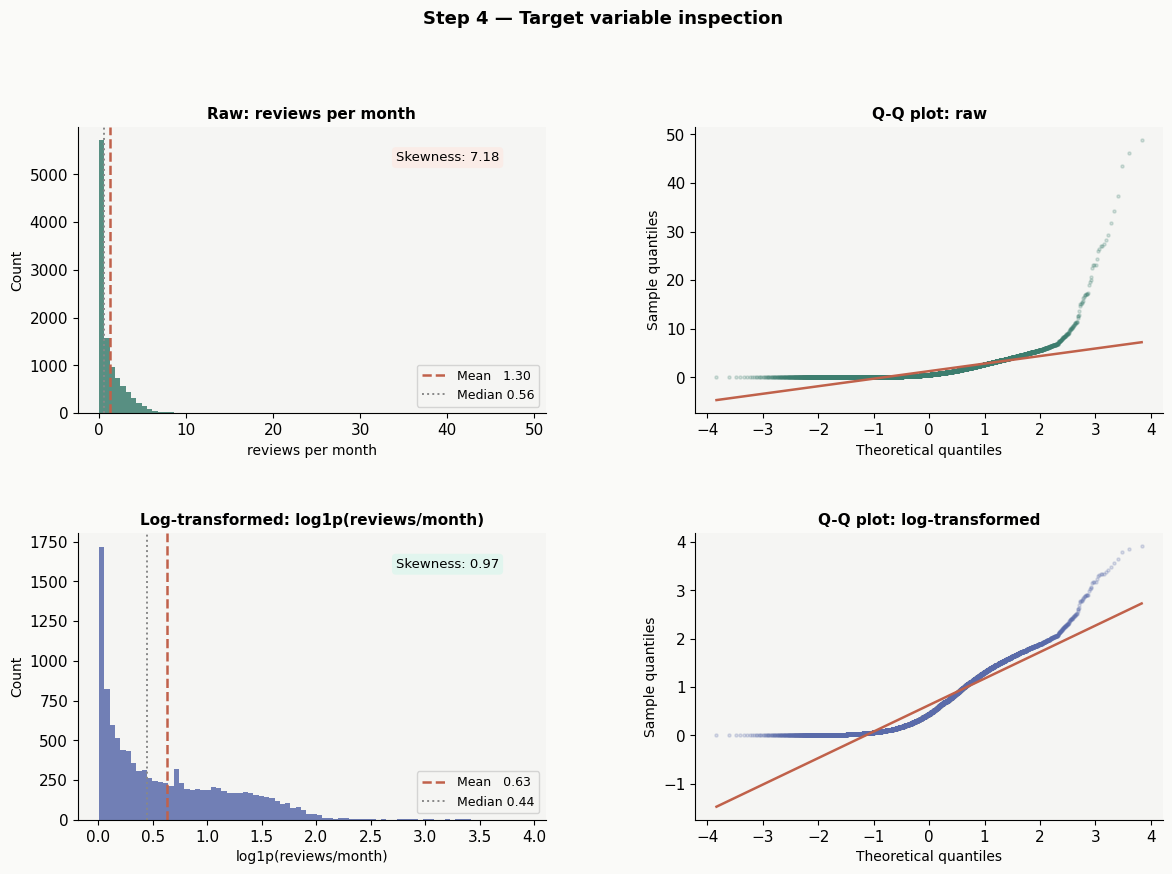

In [4]:
rpm     = model_df['reviews_per_month']
log_rpm = np.log1p(rpm)

print("RAW  — mean: {:.2f}  |  median: {:.2f}  |  skewness: {:.2f}".format(
    rpm.mean(), rpm.median(), rpm.skew()))
print("LOG  — mean: {:.2f}  |  median: {:.2f}  |  skewness: {:.2f}".format(
    log_rpm.mean(), log_rpm.median(), log_rpm.skew()))

# ── Plot ──
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)

for row, (series, label, color) in enumerate([
    (rpm,     'Raw: reviews per month',             '#3C7D6E'),
    (log_rpm, 'Log-transformed: log1p(reviews/month)', '#5A6BAA')
]):
    # Histogram
    ax_hist = fig.add_subplot(gs[row, 0])
    ax_hist.hist(series, bins=80, color=color, alpha=0.85, edgecolor='none')
    ax_hist.axvline(series.mean(),   color='#C0614A', lw=1.8, ls='--',
                    label=f'Mean   {series.mean():.2f}')
    ax_hist.axvline(series.median(), color='#888',    lw=1.4, ls=':',
                    label=f'Median {series.median():.2f}')
    ax_hist.set_title(label, fontsize=11, fontweight='semibold')
    ax_hist.set_xlabel(label.split(':')[1].strip(), fontsize=10)
    ax_hist.set_ylabel('Count', fontsize=10)
    ax_hist.legend(fontsize=9)
    ax_hist.annotate(f'Skewness: {series.skew():.2f}',
                     xy=(0.68, 0.88), xycoords='axes fraction', fontsize=9.5,
                     bbox=dict(boxstyle='round,pad=0.3',
                               facecolor='#FAECE7' if row == 0 else '#E1F5EE',
                               edgecolor='none'))

    # Q-Q plot
    ax_qq = fig.add_subplot(gs[row, 1])
    (osm, osr), (slope, intercept, _) = stats.probplot(series, dist='norm')
    ax_qq.scatter(osm, osr, color=color, alpha=0.2, s=5, rasterized=True)
    ax_qq.plot([osm[0], osm[-1]],
               [slope*osm[0]+intercept, slope*osm[-1]+intercept],
               color='#C0614A', lw=1.8)
    ax_qq.set_title(f'Q-Q plot: {"raw" if row==0 else "log-transformed"}',
                    fontsize=11, fontweight='semibold')
    ax_qq.set_xlabel('Theoretical quantiles', fontsize=10)
    ax_qq.set_ylabel('Sample quantiles',      fontsize=10)

fig.suptitle('Step 4 — Target variable inspection', fontsize=13,
             fontweight='bold', y=1.01)
plt.savefig('step4_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply the transformation and store it
model_df['log_reviews_pm'] = log_rpm

### 4. Multicollinearity check

=== VIF SCORES ===
                      Feature      VIF
nbhd_Friedrichshain-Kreuzberg 2.560364
                   nbhd_Mitte 2.549309
                  nbhd_Pankow 2.215352
                nbhd_Neukölln 1.942964
  nbhd_Tempelhof - Schöneberg 1.599542
                    log_price 1.563702
            room_Private room 1.433284
      nbhd_Treptow - Köpenick 1.385465
       host_response_time_enc 1.346391
              amenities_count 1.308556
             nbhd_Lichtenberg 1.266253
         instant_bookable_enc 1.258248
   nbhd_Steglitz - Zehlendorf 1.236558
           nbhd_Reinickendorf 1.127093
         host_acceptance_rate 1.093858
                 nbhd_Spandau 1.086606
   nbhd_Marzahn - Hellersdorf 1.084572
             room_Shared room 1.079577
              room_Hotel room 1.038075


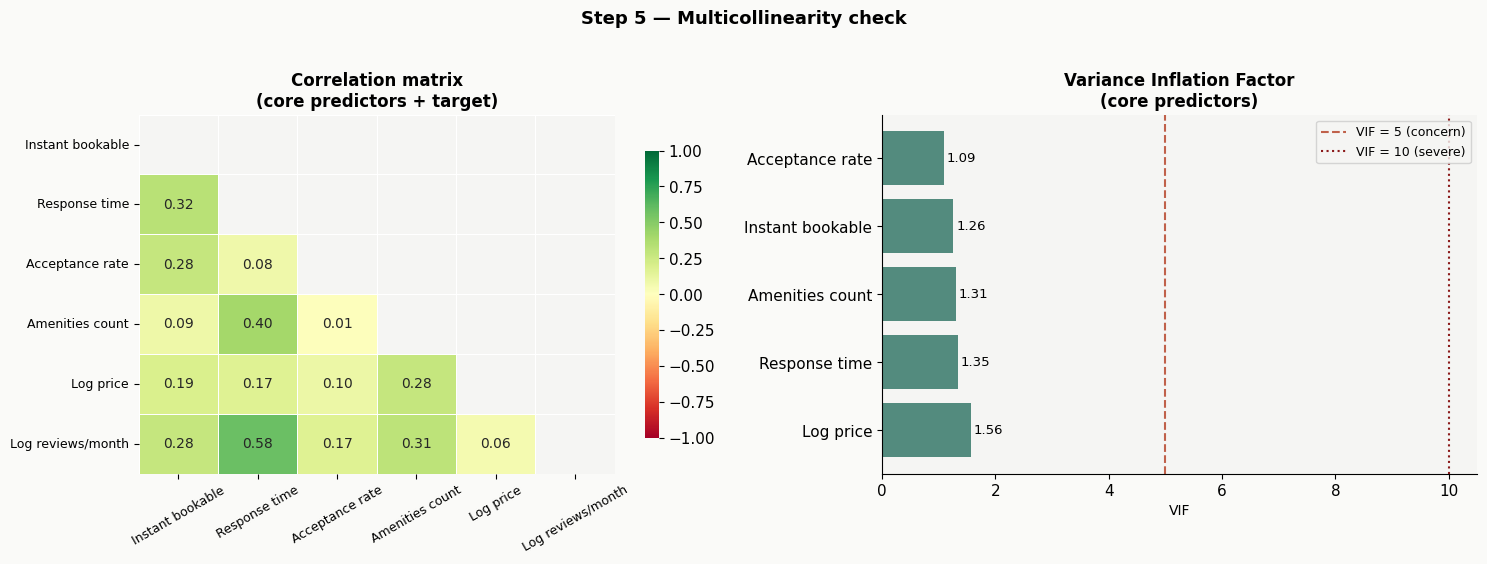

In [5]:
core_predictors = [
    'instant_bookable_enc',
    'host_response_time_enc',
    'host_acceptance_rate',
    'amenities_count',
    'log_price'
]

all_predictors = [c for c in model_df.columns
                  if c not in ('reviews_per_month', 'log_reviews_pm')]

labels = {
    'instant_bookable_enc':   'Instant bookable',
    'host_response_time_enc': 'Response time',
    'host_acceptance_rate':   'Acceptance rate',
    'amenities_count':        'Amenities count',
    'log_price':              'Log price',
    'log_reviews_pm':         'Log reviews/month'
}

# ── Correlation matrix ──
corr_cols   = core_predictors + ['log_reviews_pm']
corr_matrix = model_df[corr_cols].rename(columns=labels).corr()

# ── VIF ──
X_vif    = sm.add_constant(model_df[all_predictors].astype(float))
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False)

print("=== VIF SCORES ===")
print(vif_data.to_string(index=False))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation matrix\n(core predictors + target)',
                  fontsize=12, fontweight='semibold')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

# VIF bar chart (core predictors only)
vif_core   = vif_data[vif_data['Feature'].isin(core_predictors)].copy()
vif_core['label']  = vif_core['Feature'].map(labels)
bar_colors = ['#C0614A' if v >= 5 else '#3C7D6E' for v in vif_core['VIF']]

bars = axes[1].barh(vif_core['label'], vif_core['VIF'],
                    color=bar_colors, alpha=0.88)
axes[1].axvline(5,  color='#C0614A', lw=1.5, ls='--', label='VIF = 5 (concern)')
axes[1].axvline(10, color='#8B1A1A', lw=1.5, ls=':',  label='VIF = 10 (severe)')
axes[1].set_title('Variance Inflation Factor\n(core predictors)',
                  fontsize=12, fontweight='semibold')
axes[1].set_xlabel('VIF', fontsize=10)
axes[1].legend(fontsize=9)
for bar, val in zip(bars, vif_core['VIF']):
    axes[1].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=9.5)

fig.suptitle('Step 5 — Multicollinearity check', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step5_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Fit OLS model & read summary

In [6]:
y = model_df['log_reviews_pm']
X = sm.add_constant(model_df[all_predictors].astype(float))

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_reviews_pm   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     427.9
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:48:31   Log-Likelihood:                -7011.8
No. Observations:               10960   AIC:                         1.406e+04
Df Residuals:                   10940   BIC:                         1.421e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

### 6. Standardized coefficients (feature importance)

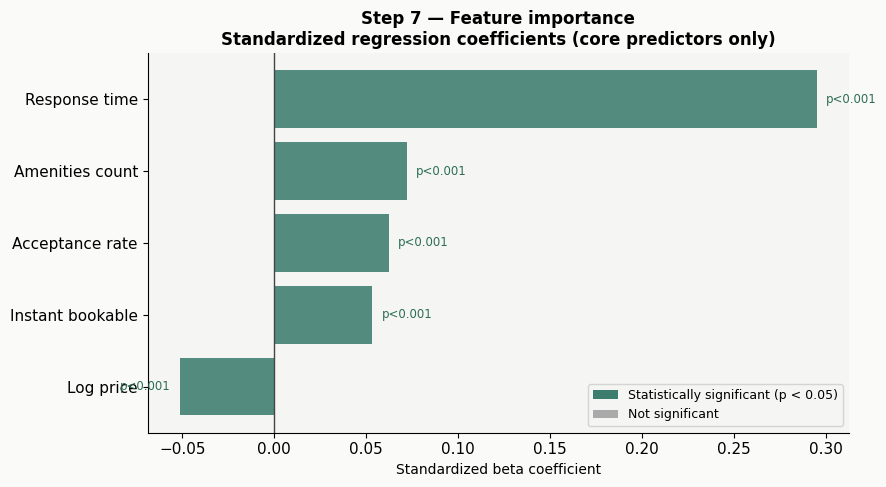


Standardized coefficients table:
         feature      beta       pvalue  significant
   Response time  0.295152 0.000000e+00         True
 Amenities count  0.072175 1.788099e-47         True
 Acceptance rate  0.062247 1.805503e-41         True
Instant bookable  0.053451 1.119272e-27         True
       Log price -0.051447 3.204089e-28         True


In [7]:
# Standardized betas allow fair comparison across predictors
# regardless of their original units
X_core      = model_df[core_predictors].astype(float)
X_std       = (X_core - X_core.mean()) / X_core.std()
X_std_const = sm.add_constant(X_std)

model_std    = sm.OLS(y, X_std_const).fit()
std_betas    = model_std.params.drop('const')
std_pvalues  = model_std.pvalues.drop('const')

std_df = pd.DataFrame({
    'feature':    std_betas.index.map(lambda x: labels.get(x, x)),
    'beta':       std_betas.values,
    'pvalue':     std_pvalues.values,
    'significant': std_pvalues.values < 0.05
}).sort_values('beta', ascending=True)

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = ['#3C7D6E' if sig else '#AAAAAA'
              for sig in std_df['significant']]
bars = ax.barh(std_df['feature'], std_df['beta'],
               color=bar_colors, alpha=0.88, edgecolor='none')
ax.axvline(0, color='#444', lw=1.0)

for bar, pval, sig in zip(bars, std_df['pvalue'], std_df['significant']):
    label = f'p={pval:.3f}' if pval >= 0.001 else 'p<0.001'
    ax.text(bar.get_width() + 0.005 if bar.get_width() >= 0
            else bar.get_width() - 0.005,
            bar.get_y() + bar.get_height() / 2,
            label, va='center',
            ha='left' if bar.get_width() >= 0 else 'right',
            fontsize=8.5,
            color='#2D6E52' if sig else '#888')

ax.set_xlabel('Standardized beta coefficient', fontsize=10)
ax.set_title('Step 7 — Feature importance\n'
             'Standardized regression coefficients (core predictors only)',
             fontsize=12, fontweight='semibold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3C7D6E', label='Statistically significant (p < 0.05)'),
    Patch(facecolor='#AAAAAA', label='Not significant')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('step7_standardized_betas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStandardized coefficients table:")
print(std_df[['feature','beta','pvalue','significant']]
      .sort_values('beta', ascending=False)
      .to_string(index=False))

### 7. Model diagnostics

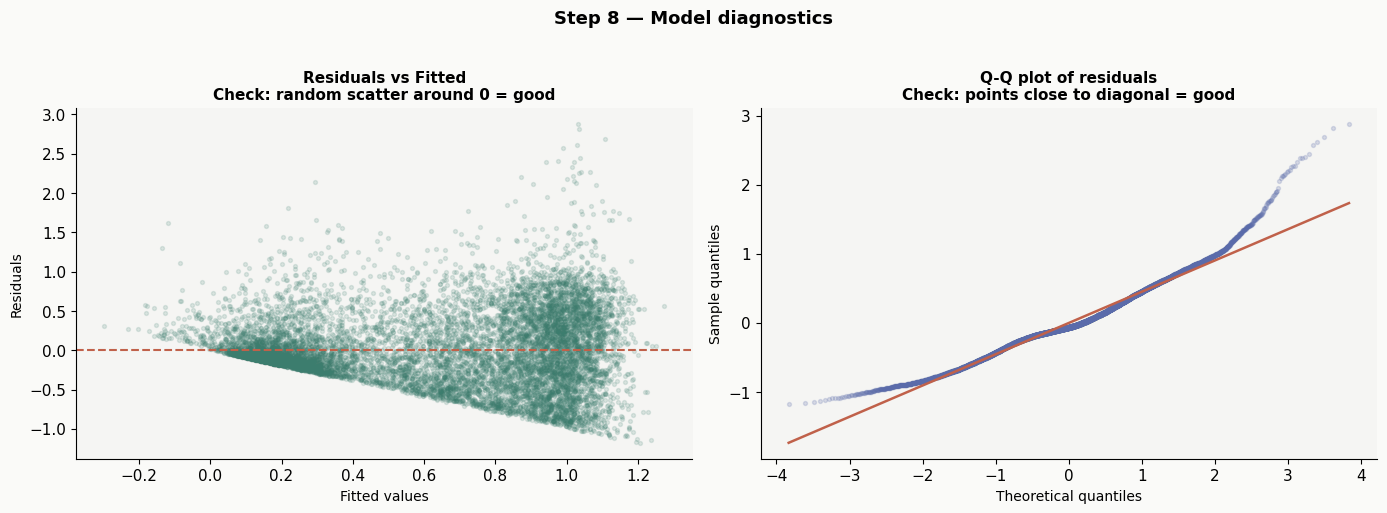

In [ ]:
fitted    = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Residuals vs Fitted ──
# What to look for: points scattered randomly around the horizontal zero line.
# A pattern (curve, funnel) signals a problem with the model.
axes[0].scatter(fitted, residuals, alpha=0.15, s=8,
                color='#3C7D6E', rasterized=True)
axes[0].axhline(0, color='#C0614A', lw=1.5, ls='--')
axes[0].set_xlabel('Fitted values',  fontsize=10)
axes[0].set_ylabel('Residuals',      fontsize=10)
axes[0].set_title('Residuals vs Fitted\n'
                  'Check: random scatter around 0 = good',
                  fontsize=11, fontweight='semibold')

# ── Q-Q plot of residuals ──
# What to look for: points close to the diagonal line.
# Heavy tails (S-curve) signal non-normal residuals.
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.2, s=8,
                color='#5A6BAA', rasterized=True)
axes[1].plot([osm[0], osm[-1]],
             [slope*osm[0]+intercept, slope*osm[-1]+intercept],
             color='#C0614A', lw=1.8)
axes[1].set_xlabel('Theoretical quantiles', fontsize=10)
axes[1].set_ylabel('Sample quantiles',      fontsize=10)
axes[1].set_title('Q-Q plot of residuals\n'
                  'Check: points close to diagonal = good',
                  fontsize=11, fontweight='semibold')

fig.suptitle('Step 8 — Model diagnostics', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step8_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## __Technical Summary__
*Note: Business Interpretation below.*
### Setup
An OLS regression was built to identify which attributes predict booking demand, 
using `reviews_per_month` as a booking proxy. The target was log-transformed 
(`log1p`) to reduce skewness from 7.18 to 0.97, satisfying OLS normality. 
Room type and neighbourhood were included as **controls** to isolate the core 
predictors below.

### Model quality
- **R² = 0.378** — explains 37.8% of demand variance; solid for cross-sectional data.
- **F = 427.9, p < 0.001** — model is statistically significant.
- **VIF < 2.6** for all predictors — no multicollinearity.
- **Heteroscedasticity** (fan-shaped residuals) was corrected with **HC3 robust 
  standard errors**. No predictor changed significance after the fix.

### Significant findings (all p < 0.05)
| Predictor | Coefficient | Approx. effect on demand |
|---|---|---|
| Host response time | +0.169 | Each tier up → ~+18.5% reviews/month |
| Instant bookable | +0.118 | Enabling it → ~+12.5% |
| Amenities count | +0.005 | Each amenity → ~+0.48% |
| Acceptance rate | +0.003 | Each +1 pp → ~+0.28% |
| Log price | −0.103 | +1% price → ~−0.10% |

> Effect = (e^β − 1) × 100, since the target is log-transformed.

### Feature importance (standardized betas)
On a common scale, **response time (β = 0.30) is ~4–5× more influential** than 
all other predictors, which cluster at 0.05–0.07. Price is the only negative 
driver (β = −0.05).

### Non-significant
Private and shared rooms don't differ in demand from entire homes — room type 
is not a meaningful driver once host behavior is accounted for.

---

## __Business Interpretation__

### Core finding
Booking demand on Berlin Airbnb is driven by **how hosts behave, not merely by what their 
listing offers.** Response time is the single strongest lever — by a wide margin — 
and the top two drivers both cost nothing to act on.

### The demand generation priority stack
| Priority | Action | Expected impact | Cost |
|---|---|---|---|
| 1 | Respond within the hour | ~+18.5% per tier | Free |
| 2 | Enable instant booking | ~+12.5% | Free |
| 3 | Add amenities (audit vs. ~29 market avg.) | ~+0.5% each, compounds | Low–Med |
| 4 | Raise acceptance rate | ~+0.28% per pp | Behavioural |
| 5 | Avoid aggressive price hikes | −0.10% per 1% | N/A |

### What this means
- **Responsiveness wins.** Moving from "within a day" to "within an hour" yields 
  ~18.5% more bookings at zero cost — the marketing equivalent of fast customer 
  service converting browsers into buyers.

- **Reduce friction.** Instant booking is Airbnb's one-click purchase: ~12.5% 
  uplift, free to enable. It should be default-on.

- **Amenities and acceptance rate compound.** Each amenity or accepted booking 
  request adds a small boost individually, but the effect stacks up — adding 
  20 amenities lifts demand by ~10%, and raising your acceptance rate from 
  70% to 95% adds another ~7%.
  
- **The market is price-inelastic.** A 10% price increase costs only ~1% of 
  demand — so price cuts are a weak demand tool. Optimize price for revenue, 
  and use behavioral levers for demand.